# GliomaGate

Cheng 2017 T1-contrast glioma MRI (Figshare 1512427), patient-wise held-out slices.
Weights from `python scripts/train.py`.

In [1]:
from pathlib import Path
import json, sys, time
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / 'app').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from app.segment import load_segmenter, predict_mask_mlp, mean_tumor_dice, image_findings
from app.lora_extract import load_lora, extract
from app.rag import GuidelineIndex
from app.ground import assemble_ledger
from app.synth import load_case, load_manifest
from app.main import overlay_rgb
from app.eval_harness import run_harness

MODELS = ROOT / 'models'
TEST = ROOT / 'data' / 'test'
mlp, _ = load_segmenter(MODELS / 'segmenter.joblib')
lora = load_lora(MODELS)
cases = []
for meta in load_manifest(TEST):
    img, labels, m = load_case(TEST, meta['case_id'])
    rec = dict(m)
    rec['image'] = img
    rec['labels'] = labels
    cases.append(rec)
log = json.loads((MODELS / 'train_log.json').read_text())
print(len(cases), 'test cases')
print('MLP', log['segmenter']['n_iter'], 'iters, final CE', round(log['segmenter']['final_loss'], 4),
      'train Dice', round(log['segmenter']['train_dice'], 3))
print('LoRA train', {k: round(v, 3) for k, v in log['lora']['train_field_acc'].items()})
print('LoRA test ', {k: round(v, 3) for k, v in log['lora']['test_field_acc'].items()})

40 test cases
MLP 208 iters, final CE 0.17 train Dice 0.41
LoRA train {'laterality': 0.912, 'lobe': 1.0, 'grade': 1.0, 'enhancement': 1.0, 'symptom': 1.0}
LoRA test  {'laterality': 0.925, 'lobe': 1.0, 'grade': 1.0, 'enhancement': 1.0, 'symptom': 1.0}


## Training loss

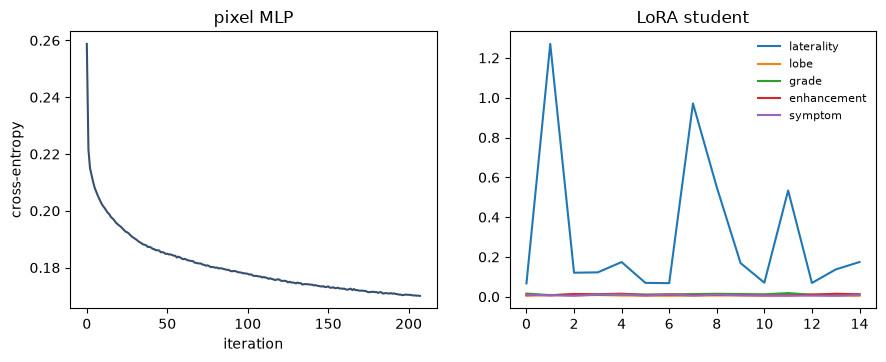

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.6))
axes[0].plot(log['segmenter']['loss_curve'], color='#355070')
axes[0].set_title('pixel MLP')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('cross-entropy')
for field, curve in log['lora']['loss_curves'].items():
    axes[1].plot(curve, label=field)
axes[1].set_title('LoRA student')
axes[1].legend(frameon=False, fontsize=8)
plt.show()

## Example case

T1-weighted post-contrast slice and the published tumor mask.

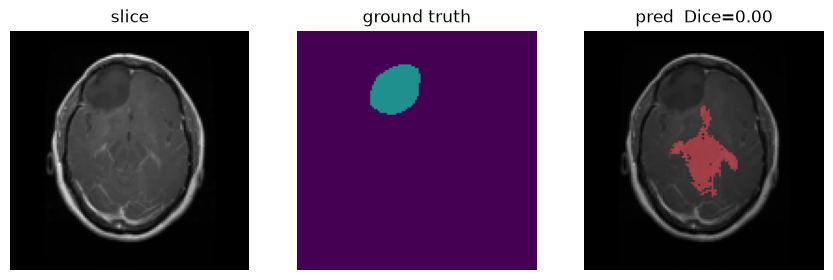

Neuro-oncology. Left-sided enhancing glioma on T1c. Grade, lobe, and presenting symptom are not specified in the record.


In [3]:
rec = cases[2]
pred = predict_mask_mlp(mlp, rec['image'])
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.4))
ax[0].imshow(rec['image'], cmap='gray')
ax[0].set_title('slice')
ax[0].axis('off')
ax[1].imshow(rec['labels'], cmap='viridis', vmin=0, vmax=2)
ax[1].set_title('ground truth')
ax[1].axis('off')
ax[2].imshow(overlay_rgb(rec['image'], pred))
ax[2].set_title(f'pred  Dice={mean_tumor_dice(pred, rec["labels"]):.2f}')
ax[2].axis('off')
plt.show()
print(rec['note'])

## Segmentation on the test set

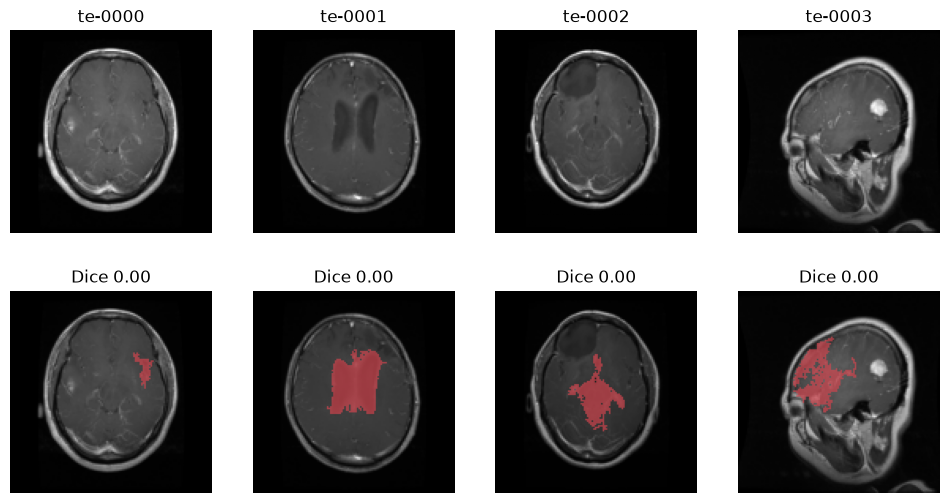

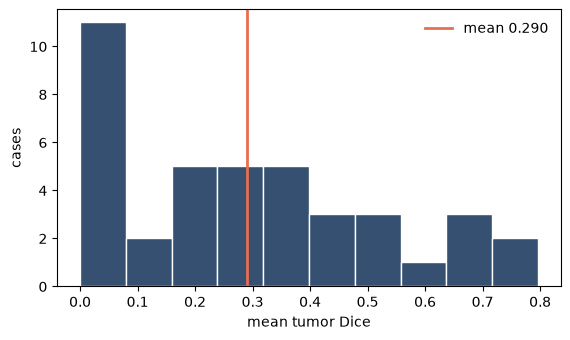

n=40  mean=0.290  p10=0.000  p90=0.667


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6.2))
for i, rec in enumerate(cases[:4]):
    pred = predict_mask_mlp(mlp, rec['image'])
    axes[0, i].imshow(rec['image'], cmap='gray')
    axes[0, i].set_title(rec['case_id'])
    axes[0, i].axis('off')
    axes[1, i].imshow(overlay_rgb(rec['image'], pred))
    axes[1, i].set_title(f'Dice {mean_tumor_dice(pred, rec["labels"]):.2f}')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('input')
axes[1, 0].set_ylabel('overlay')
plt.show()

dices = [mean_tumor_dice(predict_mask_mlp(mlp, c['image']), c['labels']) for c in cases]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(dices, bins=10, color='#355070', edgecolor='white')
ax.axvline(np.mean(dices), color='#e76f51', lw=2, label=f'mean {np.mean(dices):.3f}')
ax.set_xlabel('mean tumor Dice')
ax.set_ylabel('cases')
ax.legend(frameon=False)
plt.show()
print(f'n={len(dices)}  mean={np.mean(dices):.3f}  p10={np.percentile(dices,10):.3f}  p90={np.percentile(dices,90):.3f}')

## Structured fields and evidence

Laterality / enhancement can be supported by the mask. Grade can only be supported by retrieved guideline text.

In [5]:
rec = cases[2]
pred = predict_mask_mlp(mlp, rec['image'])
findings = image_findings(pred)
extracted = extract(lora, rec['note'], findings)
index = GuidelineIndex()
hits = index.search(index.query_for_case(rec['note'], findings, extracted), k=4)
ledger = assemble_ledger(extracted, findings, hits)
print(rec['note'], '\n')
for field, payload in ledger['fields'].items():
    print(f'{field:12} {str(payload["value"]):22} {payload["provenance"]}')
print('grounded_fraction', ledger['grounded_fraction'])
print('contradictions', ledger['contradictions'])
print('\nretrieved:')
for h in hits:
    print(f'  {h.score:.3f}  {h.title}')

Neuro-oncology. Left-sided enhancing glioma on T1c. Grade, lobe, and presenting symptom are not specified in the record. 

laterality   left                   image
lobe         unknown                ungrounded
grade        unknown                ungrounded
enhancement  yes                    image
symptom      unknown                ungrounded
grounded_fraction 0.4
contradictions []

retrieved:
  0.175  Seizure and temporal lobe
  0.175  Laterality and eloquent cortex
  0.174  Multidisciplinary glioma protocol
  0.134  Cross-modal contradiction policy


## Test scores

{
  "dice": 0.2902573477649568,
  "field_acc": {
    "laterality": 0.925,
    "lobe": 1.0,
    "grade": 1.0,
    "enhancement": 1.0,
    "symptom": 1.0
  },
  "field_acc_mean": 0.985,
  "ndcg5": 0.8986902076195168,
  "recall5": 0.0,
  "grounded_fraction": 0.4,
  "contradiction_rate": 0.225,
  "ablation": {
    "full_field_acc": 0.9850000000000001,
    "no_image_field_acc": 1.0,
    "no_rag_grounded_fraction": 0.355
  }
}


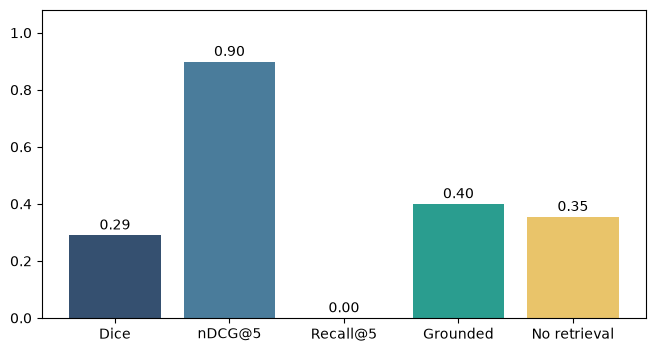

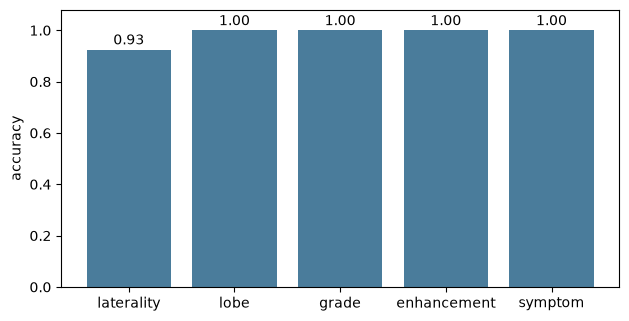

In [6]:
metrics = run_harness(cases, mlp, lora).as_dict()
print(json.dumps(metrics, indent=2))
fig, ax = plt.subplots(figsize=(7.8, 4.0))
keys = ['Dice', 'nDCG@5', 'Recall@5', 'Grounded', 'No retrieval']
vals = [metrics['dice'], metrics['ndcg5'], metrics['recall5'],
        metrics['grounded_fraction'], metrics['ablation']['no_rag_grounded_fraction']]
ax.bar(keys, vals, color=['#355070', '#4a7c9b', '#4a7c9b', '#2a9d8f', '#e9c46a'])
ax.set_ylim(0, 1.08)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.show()

fig, ax = plt.subplots(figsize=(7.2, 3.6))
names = list(metrics['field_acc'])
vals = list(metrics['field_acc'].values())
ax.bar(names, vals, color='#4a7c9b')
ax.set_ylim(0, 1.08)
ax.set_ylabel('accuracy')
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.show()

## Latency

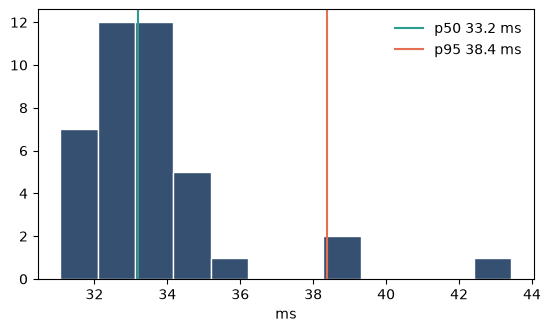

p50=33.19 ms  p95=38.37 ms  mean=33.60 ms


In [7]:
lat = []
for rec in cases:
    t0 = time.perf_counter()
    pred = predict_mask_mlp(mlp, rec['image'])
    f = image_findings(pred)
    ex = extract(lora, rec['note'], f)
    ht = index.search(index.query_for_case(rec['note'], f, ex), k=4)
    assemble_ledger(ex, f, ht)
    lat.append((time.perf_counter() - t0) * 1000)
lat.sort()
p50 = lat[len(lat) // 2]
p95 = lat[int(0.95 * (len(lat) - 1))]
fig, ax = plt.subplots(figsize=(6.4, 3.5))
ax.hist(lat, bins=12, color='#355070', edgecolor='white')
ax.axvline(p50, color='#2a9d8f', label=f'p50 {p50:.1f} ms')
ax.axvline(p95, color='#e76f51', label=f'p95 {p95:.1f} ms')
ax.set_xlabel('ms')
ax.legend(frameon=False)
plt.show()
print(f'p50={p50:.2f} ms  p95={p95:.2f} ms  mean={np.mean(lat):.2f} ms')